# Welcome to Viewport
## A world dedicated for quick experiment and data visualization

In [1]:
from chunker import Chunker
from collector import Collector
from rag import Augmentor, Retriever, Judger

### Visualization on ChromaDB

In [2]:
import chromadb

chroma_client = chromadb.PersistentClient(path="./chroma_db")
collection = chroma_client.get_collection("policy_procedures")
data = collection.get( include=["embeddings", "metadatas", "documents"] )

len(data["documents"])

204

In [3]:
import numpy as np

emb = data["embeddings"]          # lista di liste
ids = data["ids"]
metas = data.get("metadatas", None)

X = np.array(emb, dtype=np.float32)
print("shape:", X.shape)          # (n_points, dim)


shape: (204, 384)


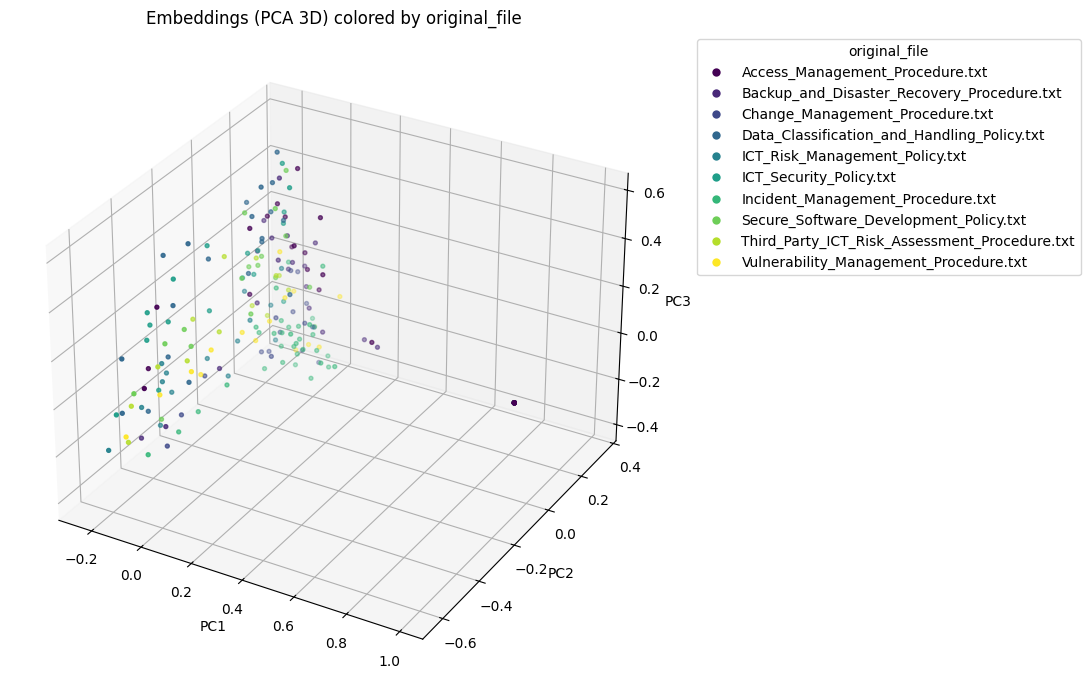

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# 1) Riduzione a 3D
pca3 = PCA(n_components=3, random_state=0)
X3 = pca3.fit_transform(X)   # X = embeddings (n, dim)

# 2) Colori per metadata
key = "original_file"
labels = [m.get(key, "NA") if m else "NA" for m in metas]

uniq = {v:i for i,v in enumerate(sorted(set(labels)))}
c = np.array([uniq[v] for v in labels])

# 3) Plot 3D
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(X3[:,0], X3[:,1], X3[:,2], s=8, c=c)
ax.set_title(f"Embeddings (PCA 3D) colored by {key}")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")

# Legenda
inv = {i:lab for lab,i in uniq.items()}  # int -> label
handles = [
    Line2D([0],[0], marker='o', linestyle='None',
           markersize=6,
           markerfacecolor=sc.cmap(sc.norm(i)),
           markeredgecolor='none',
           label=inv[i])
    for i in range(len(inv))
]
ax.legend(handles=handles, title=key, bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


### Cluster on ChromaDB

In [5]:
import numpy as np

X = np.array(data["embeddings"], dtype=np.float32)

# opzionale ma consigliato: normalizzazione L2 (≈ cosine)
Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)


In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = {}
for k in range(2, 16):
    km = KMeans(n_clusters=k, random_state=0, n_init="auto")
    labels_k = km.fit_predict(Xn)
    scores[k] = silhouette_score(Xn, labels_k)

best_k = max(scores, key=scores.get)
best_k, scores[best_k]


(2, 0.24314387142658234)

In [7]:
km = KMeans(n_clusters=best_k, random_state=0, n_init="auto")
cluster = km.fit_predict(Xn)


In [8]:
import pandas as pd
pd.Series(cluster).value_counts().sort_index()


0    184
1     20
Name: count, dtype: int64

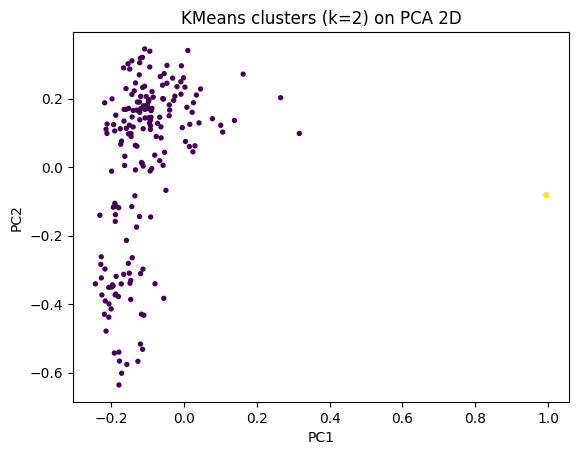

In [9]:
import matplotlib.pyplot as plt

pca2 = PCA(n_components=2, random_state=0)
X2 = pca2.fit_transform(X)  

plt.figure()
plt.scatter(X2[:,0], X2[:,1], s=8, c=cluster)
plt.title(f"KMeans clusters (k={best_k}) on PCA 2D")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()


Capire cosa c'è in ogni cluster

In [10]:
key = "original_file"
files = [m.get(key, "NA") if m else "NA" for m in metas]

df = pd.DataFrame({"cluster": cluster, "file": files})

# per ogni cluster, i file più frequenti
for cl in sorted(df["cluster"].unique()):
    print("\nCluster", cl)
    display(df[df.cluster==cl]["file"].value_counts().head(10))



Cluster 0


file
Incident_Management_Procedure.txt                33
Data_Classification_and_Handling_Policy.txt      20
Backup_and_Disaster_Recovery_Procedure.txt       19
ICT_Security_Policy.txt                          18
Access_Management_Procedure.txt                  17
Secure_Software_Development_Policy.txt           17
ICT_Risk_Management_Policy.txt                   16
Change_Management_Procedure.txt                  16
Vulnerability_Management_Procedure.txt           15
Third_Party_ICT_Risk_Assessment_Procedure.txt    13
Name: count, dtype: int64


Cluster 1


file
Incident_Management_Procedure.txt              5
Access_Management_Procedure.txt                4
Backup_and_Disaster_Recovery_Procedure.txt     4
ICT_Risk_Management_Policy.txt                 2
Change_Management_Procedure.txt                1
Data_Classification_and_Handling_Policy.txt    1
ICT_Security_Policy.txt                        1
Secure_Software_Development_Policy.txt         1
Vulnerability_Management_Procedure.txt         1
Name: count, dtype: int64

In [11]:
docs = data["documents"]
centers = km.cluster_centers_

for cl in range(best_k):
    idx = np.where(cluster == cl)[0]
    # distanza al centro (su Xn)
    d = np.linalg.norm(Xn[idx] - centers[cl], axis=1)
    reps = idx[np.argsort(d)[:]]  # 3 esempi più centrali

    print(f"\n=== Cluster {cl} (n={len(idx)}) ===")
    for r in reps:
        print("FILE:", files[r], "| ID:", data["ids"][r])
        print(docs[r][:400].replace("\n"," "), "...\n")



=== Cluster 0 (n=184) ===
FILE: ICT_Security_Policy.txt | ID: 101
Information and Communication Technology (ICT) systems are critical assets for Corporate Banking Group (CBG). These systems enable customer onboarding, payments, lending operations, treasury services, regulatory reporting, and internal collaboration. The purpose of this ICT Security Policy is to define high-level principles and mandatory security rules for protecting information, systems, and serv ...

FILE: Third_Party_ICT_Risk_Assessment_Procedure.txt | ID: 182
Contracts for ICT third parties must include (as applicable): - Confidentiality and data protection obligations aligned to CBG classification. - Right to audit and/or access to independent assurance reports. - Incident and breach notification timelines and cooperation obligations. - Subcontractor controls and approval requirements. - Service levels, availability commitments, and support response t ...

FILE: ICT_Security_Policy.txt | ID: 102
The objectives of t

### Visual on Ret

In [12]:
import pandas as pd
import numpy as np

# --- Domande ---
questions = [
"How does the identity lifecycle management process work from joiner to leaver?",
"What are the minimum steps for requesting and approving access to a system?",
"Which controls are required for Privileged Access Management (PAM)?",
"How should service accounts be created, used, and managed?",
"What is the process for revoking access when an employee leaves?",
"What operational backup requirements must be met?",
"What implementation standards are required for backups?",
"Describe the recovery execution procedure (who does what during a restore)",
"How often must backup and recovery testing be performed, and what must be documented?",
"What additional controls are recommended for ransomware resilience?",
"What are the main change types (standard/normal/emergency) and how do they differ?",
"What information must a change record contain at minimum?",
"How is change risk assessed and who approves high-risk changes?",
"What pre-implementation testing and controls are required?",
"What is required in the post-implementation review and closure steps?",
"What are the data classification levels defined?",
"What rules should staff use to classify a new dataset?",
"What handling requirements apply to higher classifications?",
"What are the retention and disposal requirements for bank data?",
"How should DLP events be reported and escalated?",
"What are the objectives of ICT risk management in the bank?",
"Describe the ICT risk governance structure and responsibilities",
"What are the required steps of the ICT risk management lifecycle?",
"How are risk acceptance and exceptions handled?",
"What documentation/evidence must be maintained for ICT risks?",
"What are the key mandatory ICT security control requirements?",
"What are the acceptable use and user obligations?",
"How does the bank manage risk acceptance and compensating controls?",
"How are compliance, monitoring, and audit handled for ICT security?",
"What governance principles guide the bank’s security program?",
"What minimum data must be logged when registering an incident?",
"WHow are incidents categorized and prioritized?",
"Describe the incident handling workflow from detection to recovery",
"What are the incident closure criteria and required documentation?",
"What emergency change/access controls apply during incidents?",
"What are the minimum security requirements across the SDLC?",
"How must secrets and keys be managed in development and CI/CD?",
"What are the logging/auditability and privacy-by-design requirements?",
"What are the rules for using open-source and third-party components?",
"How are exceptions handled and enforced in secure software development?",
"How does the bank classify third parties by criticality?",
"What due diligence is required before contract signature?",
"What should be covered in the security and architecture assessment of a supplier?",
"Which minimum contractual security clauses must be included?",
"What are the required steps for third-party exit planning and portability?",
"What are the main vulnerability sources and how are they ingested?",
"How are vulnerabilities triaged and validated (including false positives)?",
"How does the bank risk-rate and prioritize vulnerabilities?",
"What are the remediation SLAs by severity/criticality?",
"How are vulnerability exceptions and risk acceptance handled?",
"What is the bank’s Data Protection Officer (DPO) contact email and escalation hotline?",
"Which exact ISO 27001 controls (Annex A) are adopted as mandatory, with control IDs?",
"What is the bank’s approved list of endpoint security vendors and versions (e.g., EDR product name/version)?",
"What is the formal incident severity matrix with numerical thresholds (e.g., financial loss > €X, customers affected > Y)?",
"What is the official cloud landing zone architecture and network CIDR ranges used by CBG?"
]


In [13]:
import json
query_augmentor = Augmentor(type="openai")

rows = []
for q in questions:
    aug=query_augmentor.augment_query(q)

    if isinstance(aug, (dict, list)):
        aug_text = json.dumps(aug, ensure_ascii=False)
    else:
        aug_text = str(aug)

    rows.append({
            "question_original": q,
            "question_augmented": aug_text
        })
    
df_q = pd.DataFrame(rows)


In [14]:
df_q

,question_original,question_augmented
0,How does the identity lifecycle management pro...,"""identity lifecycle management process joiner ..."
1,What are the minimum steps for requesting and ...,"""minimum steps requesting approving system acc..."
2,Which controls are required for Privileged Acc...,"""required controls Privileged Access Managemen..."
3,"How should service accounts be created, used, ...","""creation usage management service accounts"""
4,What is the process for revoking access when a...,"""process revoking access employee departure"""
5,What operational backup requirements must be met?,"""operational backup requirements"""
6,What implementation standards are required for...,"""implementation standards required for backups"""
7,Describe the recovery execution procedure (who...,"""recovery execution procedure restore roles"""
8,How often must backup and recovery testing be ...,"""backup recovery testing frequency documentation"""
9,What additional controls are recommended for r...,"""ransomware resilience additional controls"""


In [15]:
def retrieve(query, k=7):
    results = collection.query(
        query_texts=[query],
        n_results=k
    )
    
    metas = results["metadatas"][0]

    return metas

In [16]:
file_retrieved = []

for q in df_q["question_augmented"]:
    metas = retrieve(q, k=7)  # la tua funzione
    files = [m["original_file"] for m in metas if "original_file" in m]
    files = list(dict.fromkeys(files))  # unique, stesso ordine
    file_retrieved.append(files)

df_q["files_retrieved"] = file_retrieved



c:\Users\cchri\Documents\Program Codes\in rag we trust\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
df_q.head(10)

,question_original,question_augmented,files_retrieved
0,How does the identity lifecycle management pro...,"""identity lifecycle management process joiner ...","[Access_Management_Procedure.txt, Third_Party_..."
1,What are the minimum steps for requesting and ...,"""minimum steps requesting approving system acc...","[Access_Management_Procedure.txt, ICT_Security..."
2,Which controls are required for Privileged Acc...,"""required controls Privileged Access Managemen...","[Access_Management_Procedure.txt, Data_Classif..."
3,"How should service accounts be created, used, ...","""creation usage management service accounts""","[Access_Management_Procedure.txt, Incident_Man..."
4,What is the process for revoking access when a...,"""process revoking access employee departure""","[Access_Management_Procedure.txt, Backup_and_D..."
5,What operational backup requirements must be met?,"""operational backup requirements""",[Backup_and_Disaster_Recovery_Procedure.txt]
6,What implementation standards are required for...,"""implementation standards required for backups""",[Backup_and_Disaster_Recovery_Procedure.txt]
7,Describe the recovery execution procedure (who...,"""recovery execution procedure restore roles""","[Backup_and_Disaster_Recovery_Procedure.txt, A..."
8,How often must backup and recovery testing be ...,"""backup recovery testing frequency documentation""",[Backup_and_Disaster_Recovery_Procedure.txt]
9,What additional controls are recommended for r...,"""ransomware resilience additional controls""","[Backup_and_Disaster_Recovery_Procedure.txt, I..."


In [ ]:
chunks_retrieved = []

for q in df_q["question_augmented"]:
    metas = retrieve(q, k=7)  # la tua funzione
    files = [m["chunk_id"] for m in metas if "chunk_id" in m]
    files = list(dict.fromkeys(files))  # unique, stesso ordine
    chunks_retrieved.append(files)

df_q["chunks_retrieved"] = chunks_retrieved

### Visual how many times a file chunk is retrieved per question

In [33]:
import pandas as pd
from collections import Counter

rows = []

for q in questions:
    total_counts = Counter()

    metas = retrieve(q)  # -> lista di dict (metadati)

    files = [m["chunk_file"] for m in metas if "chunk_file" in m]
    total_counts.update(files)  # accumula i conteggi

    # riga: question + colonne dinamiche per ogni file
    rows.append({"question": q, **dict(total_counts)})

df_counts = pd.DataFrame(rows).fillna(0)
file_cols = [c for c in df_counts.columns if c != "question"]
df_counts[file_cols] = df_counts[file_cols].astype(int)

df_counts.head()



,question,Access_Management_Procedure__chunk_011__5_1_joiner_process.txt,Access_Management_Procedure__chunk_013__5_3_leaver_process.txt,Access_Management_Procedure__chunk_009__4__roles_and_responsibilities.txt,Access_Management_Procedure__chunk_001__0_full_document.txt,Change_Management_Procedure__chunk_008__4__roles_and_responsibilities.txt,Third_Party_ICT_Risk_Assessment_Procedure__chunk_011__10__exit_planning_and_portability.txt,Access_Management_Procedure__chunk_019__10__revocation_and_emergency_removal.txt,Access_Management_Procedure__chunk_015__6__access_request_and_approval_workflow.txt,Access_Management_Procedure__chunk_018__9__access_reviews_and_recertification.txt,...,Vulnerability_Management_Procedure__chunk_002__1__introduction.txt,Vulnerability_Management_Procedure__chunk_006__5__triage_and_validation.txt,Incident_Management_Procedure__chunk_008__3_4_workaround.txt,ICT_Risk_Management_Policy__chunk_011__5_3_treatment.txt,ICT_Security_Policy__chunk_001__0_full_document.txt,Vulnerability_Management_Procedure__chunk_016__12__references.txt,Data_Classification_and_Handling_Policy__chunk_006__4_1_public.txt,ICT_Security_Policy__chunk_004__3__scope.txt,Vulnerability_Management_Procedure__chunk_001__0_full_document.txt,Incident_Management_Procedure__chunk_038__13__references__internal_.txt
0,How does the identity lifecycle management pro...,1,1,1,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,What are the minimum steps for requesting and ...,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
2,Which controls are required for Privileged Acc...,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,"How should service accounts be created, used, ...",1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,What is the process for revoking access when a...,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [34]:
import os

path = "data/test_sets.xlsx"
os.makedirs(os.path.dirname(path), exist_ok=True)

sheet_name = "augmented_queries"  # scegli tu il nome

with pd.ExcelWriter(path, engine="openpyxl", mode="a", if_sheet_exists="new") as writer:
    df_counts.to_excel(writer, sheet_name=sheet_name, index=False)


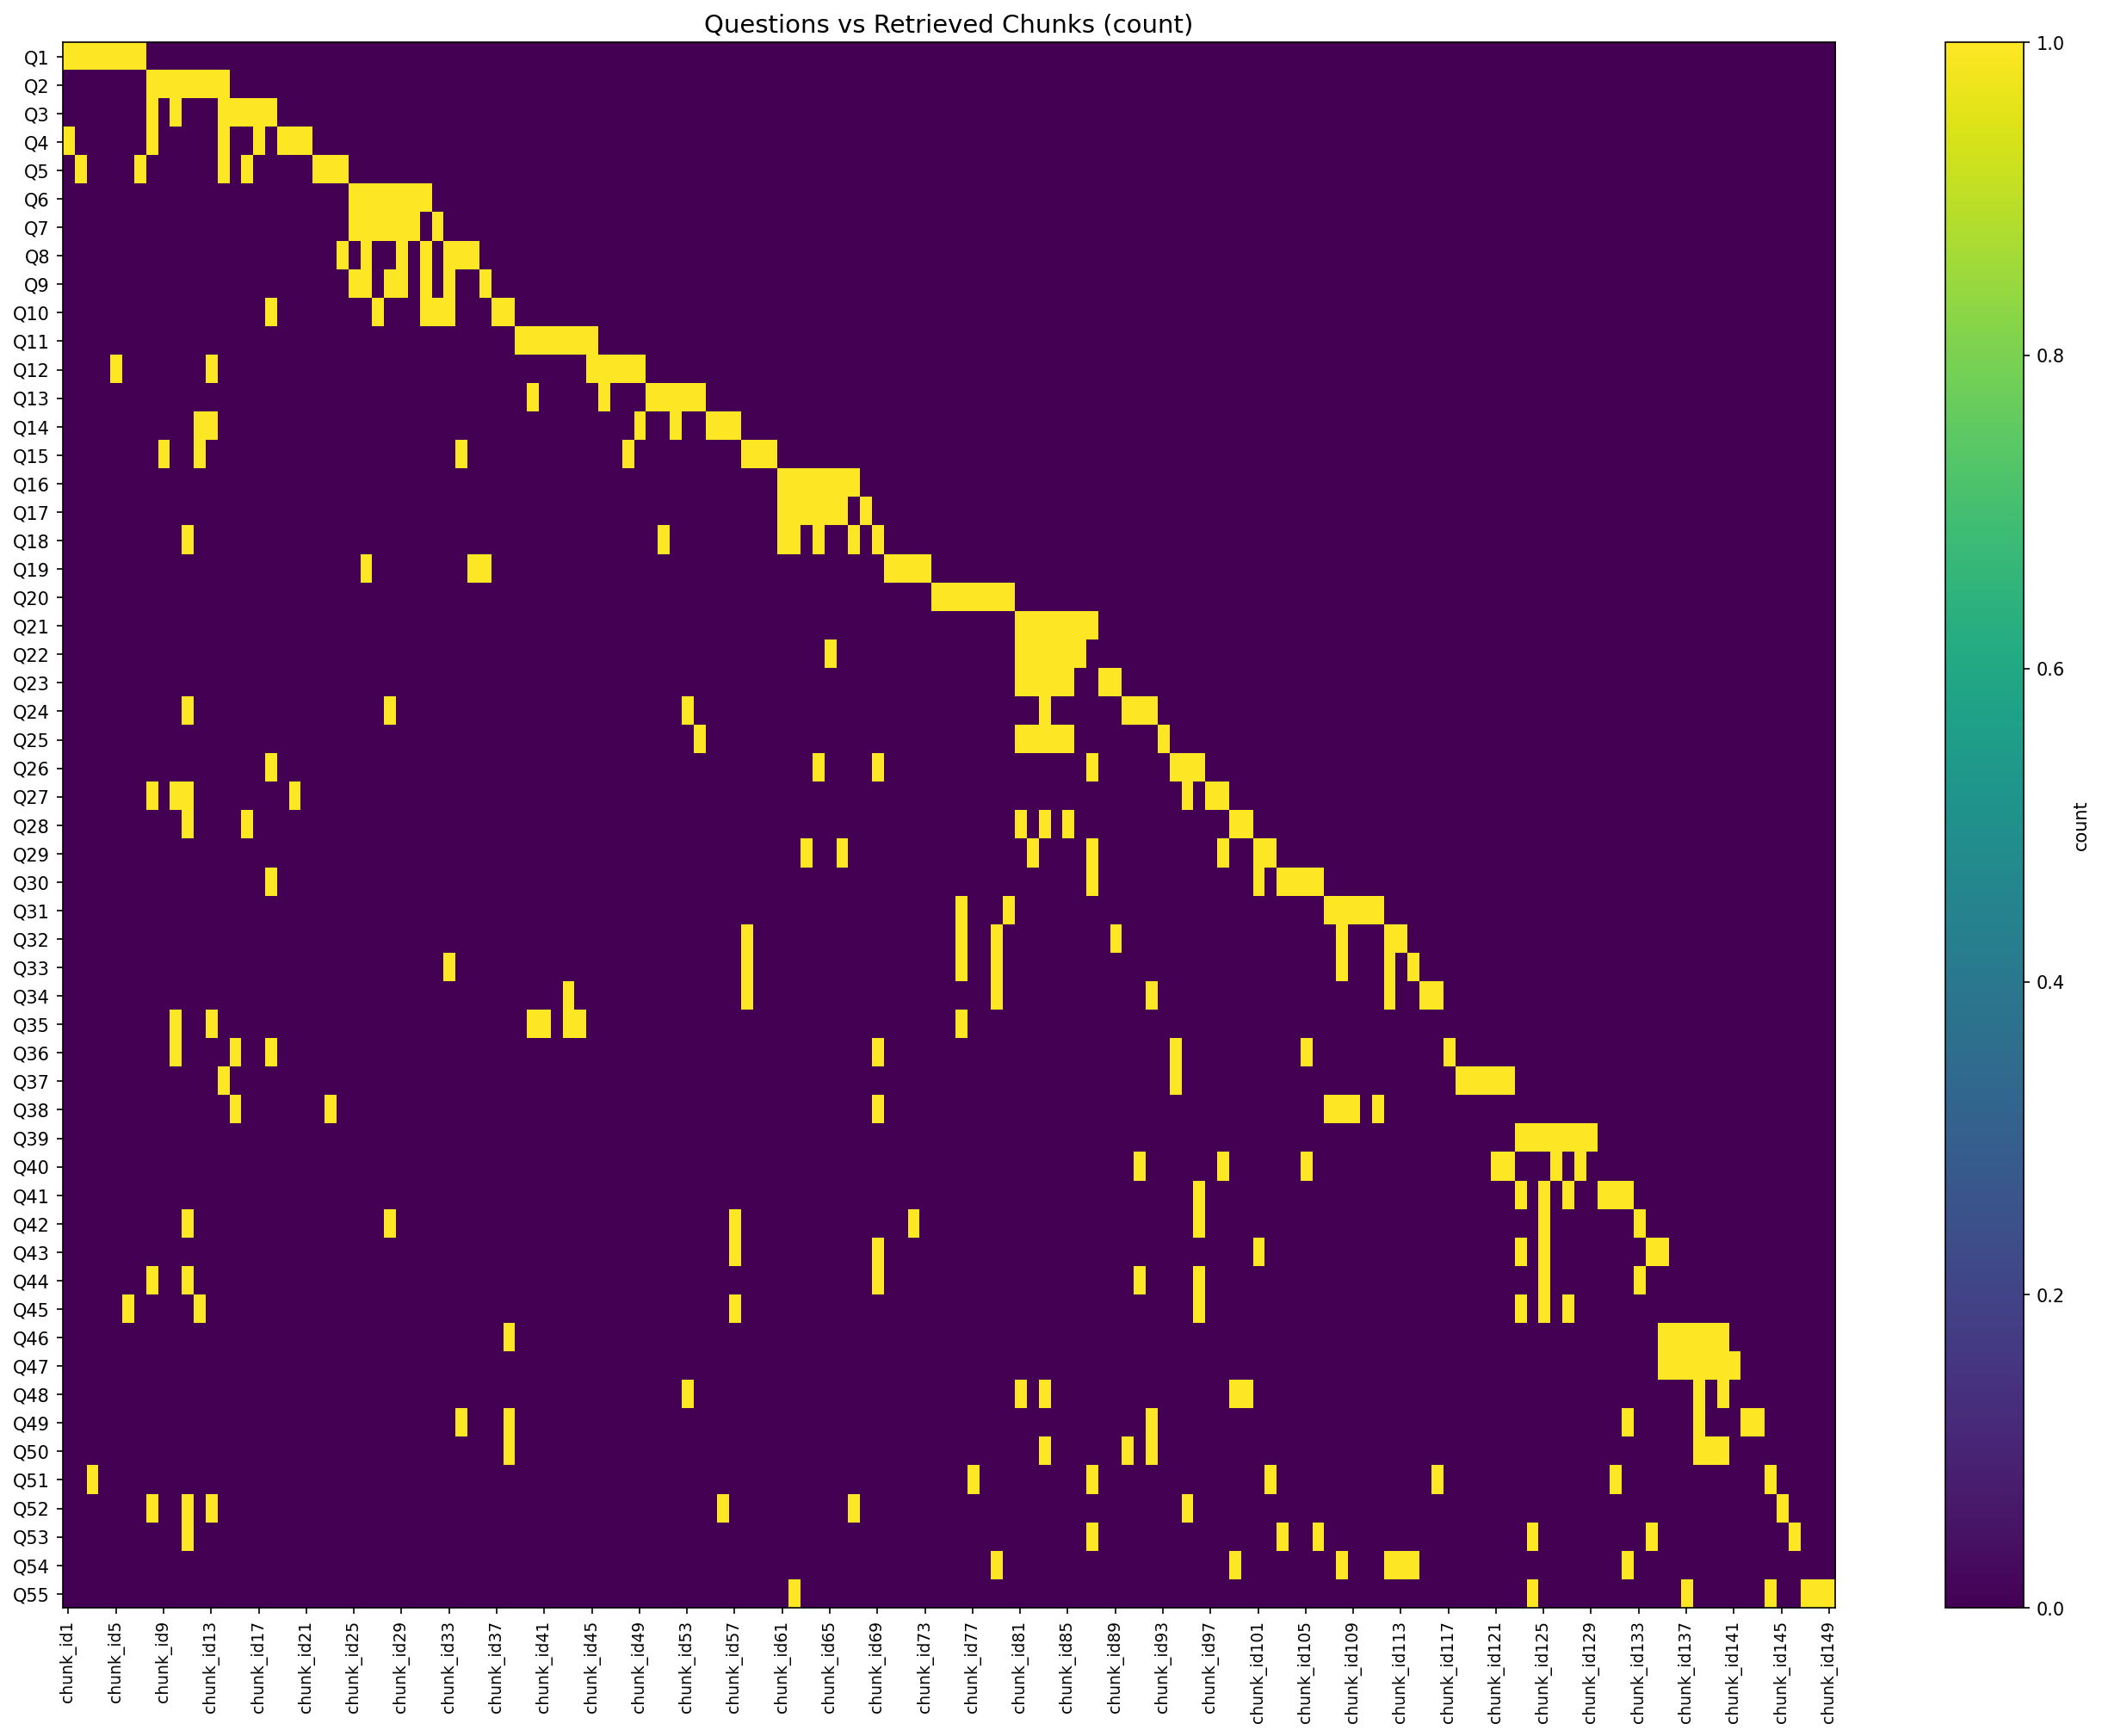

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

df_hm = df_counts.set_index("question").apply(pd.to_numeric, errors="coerce").fillna(0)

n_rows, n_cols = df_hm.shape

plt.figure(figsize=(22, max(6, n_rows * 0.35)), dpi=150)  # altezza proporzionale alle righe
plt.imshow(df_hm.values, aspect="auto", interpolation="nearest")
plt.colorbar(label="count")

# Y: Q1..Qn
plt.yticks(range(n_rows), [f"Q{i}" for i in range(1, n_rows+1)], fontsize=10)

# X: chunk_id1..chunk_idN (diradate)
step = max(1, n_cols // 30)
x_ticks = list(range(0, n_cols, step))
plt.xticks(x_ticks, [f"chunk_id{i+1}" for i in x_ticks], rotation=90, fontsize=9)

plt.title("Questions vs Retrieved Chunks (count)", fontsize=14)
plt.subplots_adjust(left=0.12, bottom=0.25)  # più spazio per label Y e X
plt.show()


### Metrics on Ret